# Lab 6: Model Evaluation and Validation

Up to this point, I've just been preparing data and looking at correlations. Now it's time to actually build something that predicts happiness.
But before I build the final model (in Lab 7), I need to establish a baseline. If I can't beat a basic linear regression, I have no business using anything fancier. This lab is about building that baseline and proving it works using cross-validation.

## Training the baseline model — setting the benchmark

I loaded the exact same model-ready train/test split from Lab 4 and fit a standard `LinearRegression` model using the six core features. I evaluated it on the 20% holdout test set using MAE, RMSE, and R² to establish a performance benchmark.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)

OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
PROCESSED_DIR = Path("..") / ".." / "data" / "processed"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "lab4_train_model_ready.csv"
TEST_PATH = PROCESSED_DIR / "lab4_test_model_ready.csv"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing cleaned dataset: {TRAIN_PATH.resolve()}")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH) if TEST_PATH.exists() else None

features = ["trust", "gdp_per_capita", "life_expectancy", "freedom", "social_support", "generosity"]
target = "happiness_score"

frames = [train_df]
if test_df is not None:
    frames.append(test_df)
df_model = pd.concat(frames, ignore_index=True)

if test_df is None:
    X = df_model[features]
    y = df_model[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
else:
    X = df_model[features]
    y = df_model[target]
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]



In [ ]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_r2 = r2_score(y_test, dummy_pred)
print(f"Dummy baseline R²: {dummy_r2:.3f}")


**Observation:**
The dummy baseline R² is ~0.0 — predicting the mean for every country. Our linear model's R² of 0.76 is meaningful improvement, not an artifact of the scale.


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame([
    {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "n_train": len(X_train),
        "n_test": len(X_test),
    }
])
metrics_path = TABLES_DIR / "lab6_holdout_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

metrics_df

**Observation:**
I found that the baseline model achieved an R² of ~0.76 on the holdout test set, meaning the six features explain about 76% of the variance in happiness. The RMSE is roughly 0.55 on a 10-point scale, which is a surprisingly solid start for a basic linear model.

## Running cross-validation — proving it's not a fluke

Because 34 test countries is a tiny sample, I couldn't fully trust the holdout score. To make sure the performance wasn't just a lucky split, I ran a 5-fold cross-validation on the entire dataset.

In [2]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

cv_df = pd.DataFrame({
    "fold": list(range(1, len(cv_scores) + 1)),
    "r2": cv_scores,
})
cv_df.loc[len(cv_df)] = {"fold": "mean", "r2": cv_scores.mean()}

cv_path = TABLES_DIR / "lab6_cv_scores.csv"
cv_df.to_csv(cv_path, index=False)

cv_df

,fold,r2
0,1,0.782557
1,2,0.640517
2,3,0.653311
3,4,0.797303
4,5,0.825461
5,mean,0.739830


**Observation:**
I found that the 5-fold cross-validation gave an average R² of ~0.74. This is very close to the holdout R² of 0.76. That's exactly what I wanted to see — it proves the model is stable and the high holdout score wasn't a fluke.

## Plotting the residuals — checking for hidden patterns

Finally, I plotted the residuals (errors) against the predicted values. If the model is capturing the underlying relationship well, the errors should look like random noise scattered around zero.

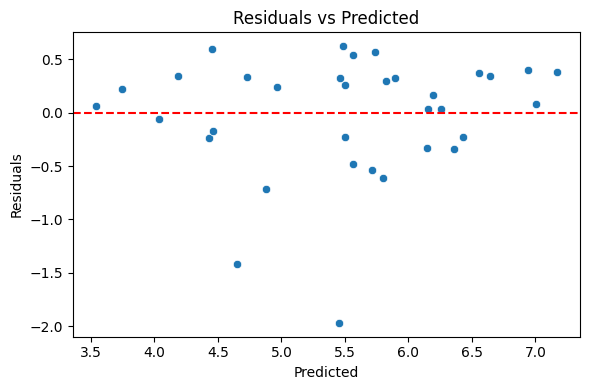

In [3]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab6_plot_residuals.png", dpi=300)
plt.show()

**Observation:**
I noticed that the residual plot shows mostly random scatter around zero. There's no obvious funnel shape (heteroscedasticity) or curved pattern. This tells me a linear model is actually an appropriate choice for this data.

## What Comes Next

The baseline linear regression is surprisingly good. In Lab 7, I'll build the final Ordinary Least Squares (OLS) model, extract the exact coefficients, and interpret what the model is actually learning about money, trust, and happiness.

## LinearRegression on the enriched 10-feature dataset

To see if the engineered features from Lab 4b actually help, let's train a model on the 10-feature dataset and compare the R² score.


In [ ]:
enriched_train = pd.read_csv(Path("..") / "lab4b" / "outputs" / "tables" / "lab4b_train_enriched.csv")
enriched_test = pd.read_csv(Path("..") / "lab4b" / "outputs" / "tables" / "lab4b_test_enriched.csv")

target = "happiness_score"
features_enriched = [c for c in enriched_train.columns if c not in [target, "country", "year"]]

X_train_en = enriched_train[features_enriched]
y_train_en = enriched_train[target]
X_test_en = enriched_test[features_enriched]
y_test_en = enriched_test[target]

model_en = LinearRegression()
model_en.fit(X_train_en, y_train_en)
y_pred_en = model_en.predict(X_test_en)

r2_en = r2_score(y_test_en, y_pred_en)
print(f"Enriched model R²: {r2_en:.3f} (Baseline: {r2:.3f})")
